In [1]:
%pip install -U -r requirements.txt

  Using cached aiohttp-3.11.11-cp310-cp310-macosx_10_9_x86_64.whl.metadata (7.7 kB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt

from pipeline import Pipeline, get_ticker_price_pdf, plot_returns

pipeline = Pipeline(lookback_periods=30, forward_periods=7)


DEBUG:pipeline: Creating Spark session...
25/01/02 20:54:42 WARN Utils: Your hostname, 0xglebs-MacBook-Pro.local resolves to a loopback address: 127.0.0.1; using 192.168.1.107 instead (on interface en0)
25/01/02 20:54:42 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/01/02 20:54:43 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
DEBUG:pipeline: Spark session created.


In [3]:
reload = False

candles_file_name = "ohlcv1d"
candles_path = f"{pipeline.data_dir}/{candles_file_name}.csv"

if reload:
    candles_df = await pipeline.get_candles_df(timeframe="1d")  # noqa: PLE1142
    pipeline.save_csv(candles_file_name, candles_df)

candles_df = pipeline.spark.read.csv(candles_path, header=True, inferSchema=True)

In [4]:
BTC_price = get_ticker_price_pdf("BTC", candles_df);
ETH_price = get_ticker_price_pdf("ETH", candles_df);
SOL_price = get_ticker_price_pdf("SOL", candles_df);

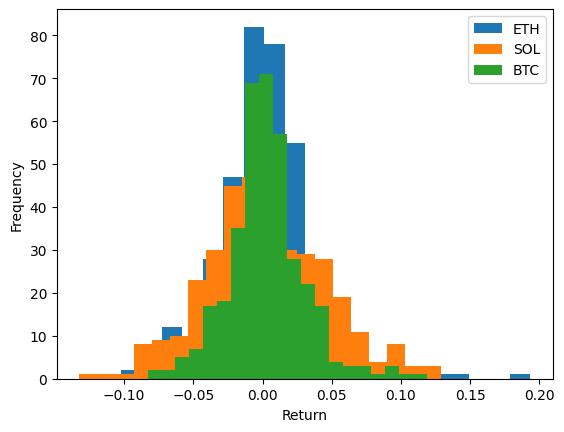

In [5]:
# tickers = candles_df.select("symbol").distinct().toPandas()["symbol"].tolist()
tickers = ["ETH", "SOL", "BTC"]
prices = [get_ticker_price_pdf(ticker, candles_df) for ticker in tickers]

plot_returns(prices)
plt.show()

In [6]:


BTC_price = get_ticker_price_pdf("BTC", candles_df)
pipeline.test_stationarity(BTC_price)

BTC_price_return = BTC_price.pct_change()[1:]
BTC_price_return.name = "BTC_price_return"
pipeline.test_stationarity(BTC_price_return)


ERROR:pipeline: BTC is likely not stationary
INFO:pipeline: BTC_price_return is likely stationary


True

In [7]:

ETH_price = get_ticker_price_pdf("ETH", candles_df)
ETH_price_return = ETH_price.pct_change()[1:]
ETH_price_return.name = "ETH_price_return"
pipeline.test_stationarity(ETH_price_return)

SOL_price = get_ticker_price_pdf("SOL", candles_df)
SOL_price_return = SOL_price.pct_change()[1:]
SOL_price_return.name = "SOL_price_return"
pipeline.test_stationarity(SOL_price_return)

RLB_price = get_ticker_price_pdf("RLB", candles_df)
RLB_price_return = RLB_price.pct_change()[1:]
RLB_price_return.name = "RLB_price_return"
pipeline.test_stationarity(RLB_price_return)



pipeline.test_cointegration(BTC_price_return, ETH_price_return)
pipeline.test_cointegration(BTC_price_return, SOL_price_return)
pipeline.test_cointegration(ETH_price_return, SOL_price_return)
pipeline.test_cointegration(RLB_price_return, SOL_price_return)


INFO:pipeline: ETH_price_return is likely stationary
INFO:pipeline: SOL_price_return is likely stationary
INFO:pipeline: RLB_price_return is likely stationary
INFO:pipeline: BTC_price_return and ETH_price_return are likely cointegrated
DEBUG:pipeline: result: (np.float64(-18.736745168691122), np.float64(1.3479121198480644e-29), array([-3.92669686, -3.35292121, -3.05609014]))
INFO:pipeline: BTC_price_return and SOL_price_return are likely cointegrated
DEBUG:pipeline: result: (np.float64(-8.601663551033127), np.float64(9.051524363330176e-13), array([-3.92669686, -3.35292121, -3.05609014]))
INFO:pipeline: ETH_price_return and SOL_price_return are likely cointegrated
DEBUG:pipeline: result: (np.float64(-8.054572195658185), np.float64(2.2033853012131597e-11), array([-3.92669686, -3.35292121, -3.05609014]))
INFO:pipeline: RLB_price_return and SOL_price_return are likely cointegrated
DEBUG:pipeline: result: (np.float64(-11.02186869303392), np.float64(7.375662337067672e-19), array([-3.92669686

True

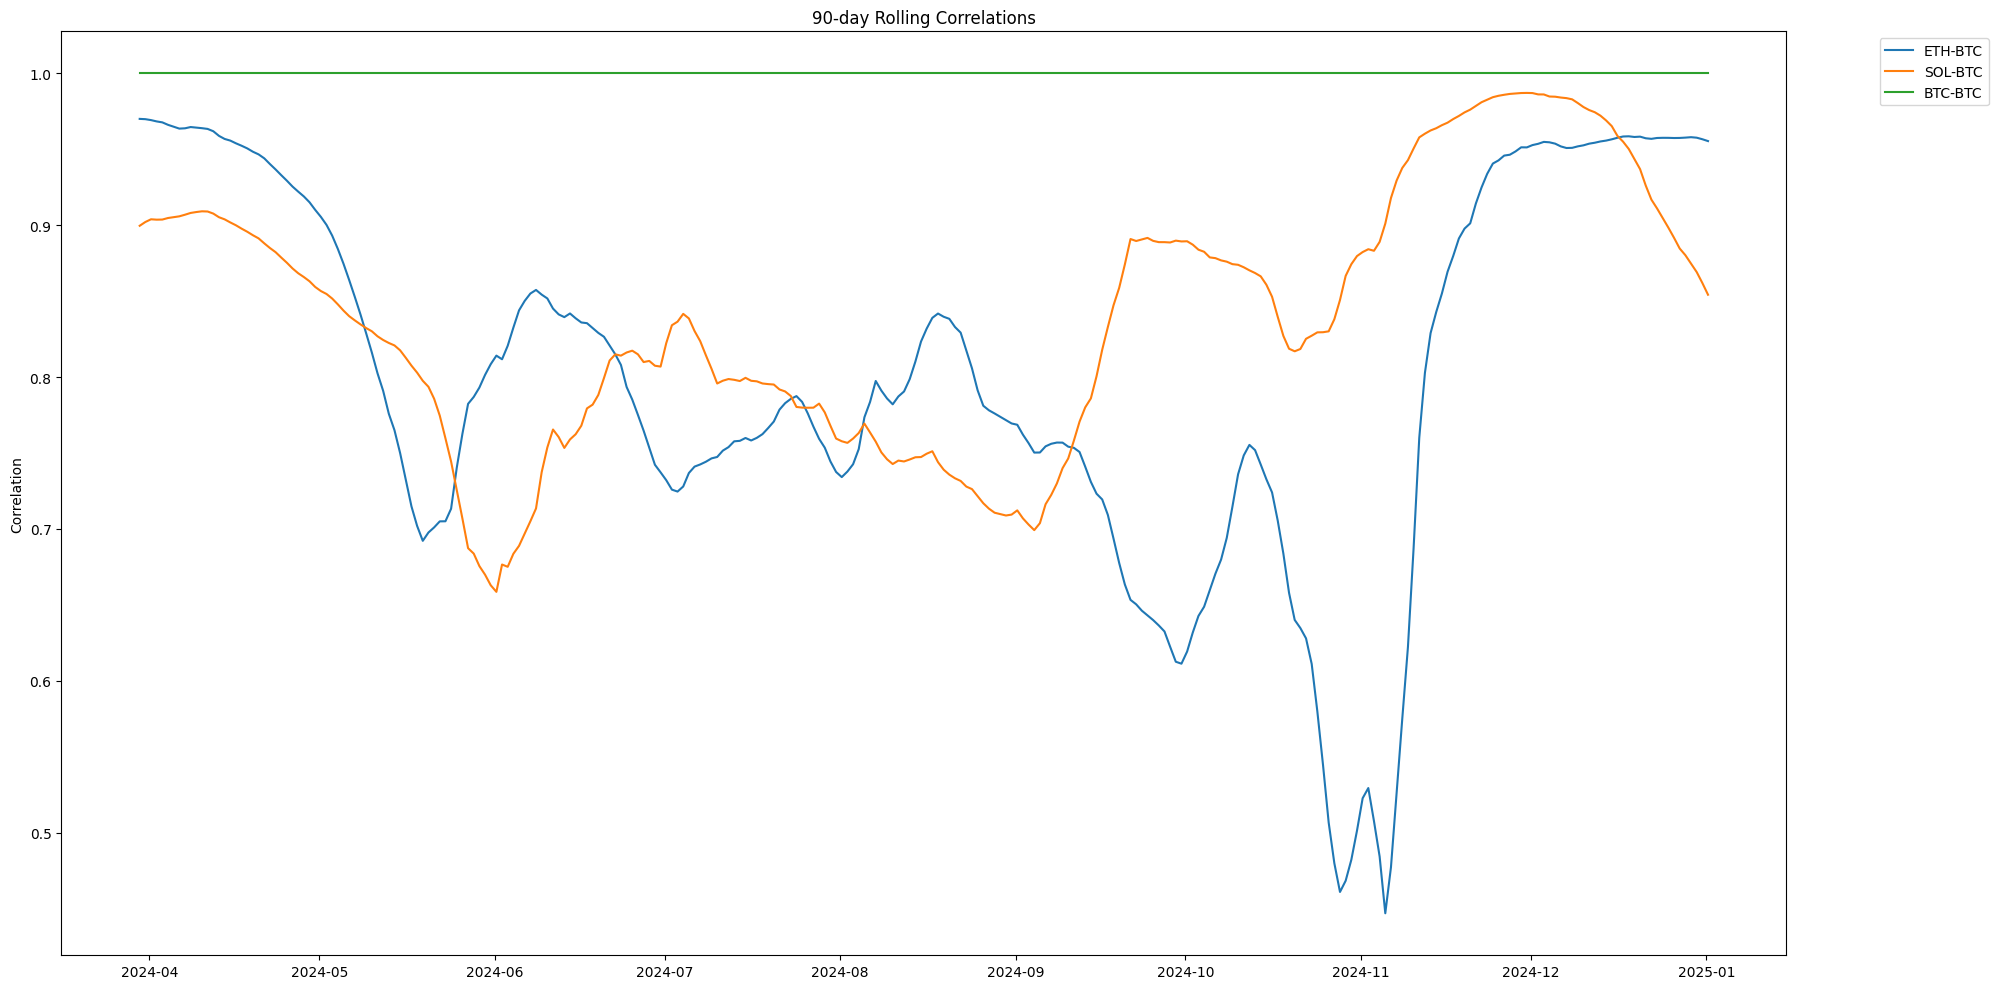

In [8]:
rolling_correlation_window = 90

# Calculate rolling correlations between all pairs of tickers
correlations = {}
for i, ticker1 in enumerate(tickers):
    price1 = prices[i]
    ticker2 = "BTC"
    price2 = prices[tickers.index(ticker2)]
    corr = price1.rolling(window=rolling_correlation_window).corr(price2)
    pair = f"{ticker1}-{ticker2}"
    correlations[pair] = corr

# Plot correlations
plt.figure(figsize=(20, 10))
for pair, corr in correlations.items():
    plt.plot(corr.index, corr.values, label=pair)
plt.ylabel("Correlation")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title(f"{rolling_correlation_window}-day Rolling Correlations")
plt.tight_layout()
plt.show()


In [10]:
from pyspark.sql import DataFrame
from pyspark.sql import functions as F
from pyspark.sql import window as W

# Get oldest and latest timestamps
oldest = candles_df.select(F.min("timestamp")).first()[0]
latest = candles_df.select(F.max("timestamp")).first()[0]
pipeline.logger.info("Data range: %s to %s", oldest, latest)

symbol_window = W.Window.partitionBy("symbol").orderBy("timestamp")
window_size = 30
rolling_window = symbol_window.rowsBetween(-window_size + 1, 0)


def with_forward_return(df: DataFrame) -> DataFrame:
    forward_window = 7
    forward_window = symbol_window.rowsBetween(1, forward_window)
    return df.withColumn(
        "forward_return", F.exp(F.sum("return").over(forward_window)) - 1
    ).withColumn(
        "price_zscore_fw_return_corr",
        F.corr(F.col("price_zscore"), F.col("forward_return")).over(rolling_window),
    )

return_df = (
    candles_df
    .transform(pipeline.with_returns)
    .transform(pipeline.with_bollinger)
    .transform(pipeline.with_zscore)
    .transform(pipeline.with_auto_regression)
    .transform(with_forward_return)
)

return_df.describe().show()
return_df.show()

INFO:pipeline: Data range: 2024-01-01 07:00:00 to 2025-01-01 07:00:00
DEBUG:pipeline: Calculating returns...


AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column or function parameter with name `high` cannot be resolved. Did you mean one of the following? [`sma`, `close`, `count`, `return`, `symbol`].;
'Project [symbol#23, timestamp#17, close#21, count#141L, return#146, log_return#154, cum_return#163, sma#173, price_stddev#183, return_stddev#202, bollinger_upper#222, bollinger_lower#234, CASE WHEN (count#141L >= cast(30 as bigint)) THEN max('high) windowspecdefinition(symbol#23, timestamp#17 ASC NULLS FIRST, specifiedwindowframe(RowFrame, -29, currentrow$())) END AS max#248]
+- Project [symbol#23, timestamp#17, close#21, count#141L, return#146, log_return#154, cum_return#163, sma#173, price_stddev#183, return_stddev#202, bollinger_upper#222, (sma#173 - (price_stddev#183 * cast(2 as double))) AS bollinger_lower#234]
   +- Project [symbol#23, timestamp#17, close#21, count#141L, return#146, log_return#154, cum_return#163, sma#173, price_stddev#183, return_stddev#202, (sma#173 + (price

In [ ]:
# Convert to pandas for plotting
btc_df = return_df.filter(F.col("symbol") == F.lit("BTC"))
btc_df.show()
btc_pdf = btc_df.toPandas()

In [ ]:
# Plot cumulative returns
plt.figure(figsize=(20, 10))
plt.plot(btc_pdf["timestamp"], btc_pdf["close"], label="Close")
plt.plot(btc_pdf["timestamp"], btc_pdf["sma"], label="SMA")
plt.plot(btc_pdf["timestamp"], btc_pdf["max"], label="Max")
plt.plot(btc_pdf["timestamp"], btc_pdf["min"], label="Min")
plt.plot(btc_pdf["timestamp"], btc_pdf["bollinger_upper"], label="mu + 2 * sigma")
plt.plot(btc_pdf["timestamp"], btc_pdf["bollinger_lower"], label="mu - 2 * sigma")
plt.ylabel("Return")
plt.title("BTC")
plt.legend()
plt.show()

plt.figure(figsize=(20, 10))
plt.plot(
    btc_pdf["timestamp"],
    btc_pdf["price_zscore_fw_return_corr"],
    label="Price Z-score Forward Return Correlation",
)
plt.plot(btc_pdf["timestamp"], btc_pdf["auto_regression"], label="Auto-Regression")

plt.ylabel("Value")
plt.axhline(y=0, color="r", linestyle="--")
plt.title("BTC Zscore")
plt.legend()
plt.show()